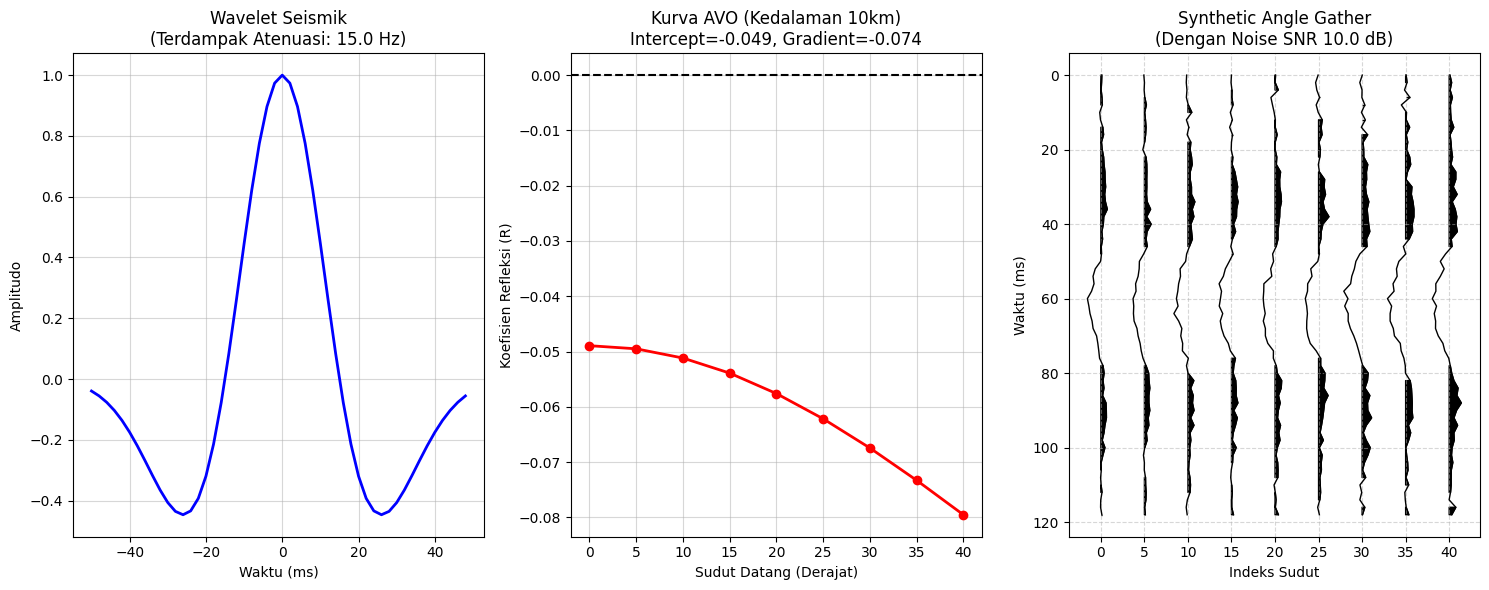


--- Memulai Generasi Dataset ML ---
Bentuk Input Data (X): (1000, 60, 9) -> (Sampel, Waktu, Sudut)
Bentuk Target Data (y): (1000, 3) -> (Sampel, Vp, Vs, Rho)
Dataset berhasil disimpan di direktori: ./seismic_ml_dataset


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNGSI FISIKA DASAR
# ==========================================
def shuey_2term(vp1, vs1, rho1, vp2, vs2, rho2, angles_deg):
    dvp = vp2 - vp1
    dvs = vs2 - vs1
    drho = rho2 - rho1
    vp_avg = (vp1 + vp2) / 2.0
    vs_avg = (vs1 + vs2) / 2.0
    rho_avg = (rho1 + rho2) / 2.0
    
    A = 0.5 * (dvp / vp_avg + drho / rho_avg)
    B = 0.5 * (dvp / vp_avg) - 2.0 * (vs_avg / vp_avg)**2 * (drho / rho_avg + 2.0 * dvs / vs_avg)
    
    theta_rad = np.radians(angles_deg)
    R_theta = A + B * np.sin(theta_rad)**2
    return R_theta, A, B

def ricker_wavelet(freq, length, dt):
    t = np.arange(-length/2, (length)/2, dt)
    y = (1.0 - 2.0 * (np.pi**2) * (freq**2) * (t**2)) * np.exp(-(np.pi**2) * (freq**2) * (t**2))
    return t, y

def add_noise(signal, snr_db):
    """Menambahkan Gaussian Noise ke sinyal berdasarkan nilai SNR dalam dB"""
    signal_power = np.mean(signal**2)
    noise_power = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

# ==========================================
# 2. PARAMETERISASI DUNIA NYATA (KEDALAMAN 10.000 m)
# ==========================================
# Kondisi: Ultra-deep, highly compacted, low porosity
# Lapisan 1: Deep Hard Shale
vp1_base, vs1_base, rho1_base = 5200.0, 3100.0, 2.65  
# Lapisan 2: Tight Gas Sand (Porositas rendah)
vp2_base, vs2_base, rho2_base = 4900.0, 3250.0, 2.55  

angles = np.arange(0, 45, 5) # Sudut observasi
freq_wavelet = 15.0          # Atenuasi tinggi: frekuensi turun drastis di 10km (15 Hz)
dt = 0.002                   # 2 ms sampling rate
snr = 10.0                   # Signal to Noise Ratio 10 dB (kondisi lapangan)

# Hitung R(theta) & buat wavelet untuk visualisasi
R_theta_base, A_base, B_base = shuey_2term(vp1_base, vs1_base, rho1_base, vp2_base, vs2_base, rho2_base, angles)
t_wavelet, wavelet = ricker_wavelet(freq_wavelet, length=0.1, dt=dt)

# ==========================================
# 3. VISUALISASI: WAVELET, AVO CURVE, & NOISY SIGNAL
# ==========================================
# Buat sinyal 1D untuk satu sampel
n_samples = 60 
reflector_index = int(n_samples / 2)
time_axis = np.arange(0, n_samples * dt, dt) * 1000 
synthetic_gather = np.zeros((n_samples, len(angles)))

for i, r in enumerate(R_theta_base):
    rc_series = np.zeros(n_samples)
    rc_series[reflector_index] = r 
    trace = np.convolve(rc_series, wavelet, mode='same')
    synthetic_gather[:, i] = add_noise(trace, snr) # Injeksi noise di sini

fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# Plot 1: Wavelet (Efek Atenuasi)
axs[0].plot(t_wavelet * 1000, wavelet, color='blue', lw=2)
axs[0].set_title(f"Wavelet Seismik\n(Terdampak Atenuasi: {freq_wavelet} Hz)")
axs[0].set_xlabel("Waktu (ms)")
axs[0].set_ylabel("Amplitudo")
axs[0].grid(True, alpha=0.5)

# Plot 2: AVO Curve (Incidence Angle vs R)
axs[1].plot(angles, R_theta_base, marker='o', color='red', lw=2)
axs[1].set_title(f"Kurva AVO (Kedalaman 10km)\nIntercept={A_base:.3f}, Gradient={B_base:.3f}")
axs[1].set_xlabel("Sudut Datang (Derajat)")
axs[1].set_ylabel("Koefisien Refleksi (R)")
axs[1].axhline(0, color='black', linestyle='--')
axs[1].grid(True, alpha=0.5)

# Plot 3: Sinyal Seismik (Angle Gather) dengan Noise
for i, angle in enumerate(angles):
    trace_offset = synthetic_gather[:, i] * 5 + i # Skala amplitudo dikali 5 agar terlihat 
    axs[2].plot(trace_offset, time_axis, color='black', linewidth=1)
    axs[2].fill_betweenx(time_axis, i, trace_offset, where=(trace_offset > i), color='black')

axs[2].invert_yaxis()
axs[2].set_title(f"Synthetic Angle Gather\n(Dengan Noise SNR {snr} dB)")
axs[2].set_xlabel("Indeks Sudut")
axs[2].set_xticks(np.arange(len(angles)))
axs[2].set_xticklabels(angles)
axs[2].set_ylabel("Waktu (ms)")
axs[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 4. GENERASI DATASET ML & PENYIMPANAN
# ==========================================
print("\n--- Memulai Generasi Dataset ML ---")
num_dataset_samples = 1000 # Buat 1000 variasi geologi
X_data = [] # Input (Fitur) untuk ML: Sinyal seismik
y_data = [] # Output (Target) untuk ML: Properti batuan (Vp, Vs, Rho)

for _ in range(num_dataset_samples):
    # Simulasi Monte Carlo: Acak nilai properti +/- 5% dari base value
    vp1 = np.random.normal(vp1_base, vp1_base * 0.05)
    vs1 = np.random.normal(vs1_base, vs1_base * 0.05)
    rho1 = np.random.normal(rho1_base, rho1_base * 0.05)
    
    vp2 = np.random.normal(vp2_base, vp2_base * 0.05)
    vs2 = np.random.normal(vs2_base, vs2_base * 0.05)
    rho2 = np.random.normal(rho2_base, rho2_base * 0.05)
    
    # Hitung refleksi
    R_t, _, _ = shuey_2term(vp1, vs1, rho1, vp2, vs2, rho2, angles)
    
    # Buat gather
    gather = np.zeros((n_samples, len(angles)))
    for i, r in enumerate(R_t):
        rc = np.zeros(n_samples)
        rc[reflector_index] = r
        trace = np.convolve(rc, wavelet, mode='same')
        # Injeksi variasi noise secara acak per sampel (SNR 5 dB - 15 dB)
        random_snr = np.random.uniform(5.0, 15.0) 
        gather[:, i] = add_noise(trace, random_snr)
        
    X_data.append(gather)
    # Menyimpan target yang ingin diinversi oleh Machine Learning (misal Vp2, Vs2, Rho2)
    y_data.append([vp2, vs2, rho2])

# Konversi list ke Numpy Array
X_data = np.array(X_data)
y_data = np.array(y_data)

print(f"Bentuk Input Data (X): {X_data.shape} -> (Sampel, Waktu, Sudut)")
print(f"Bentuk Target Data (y): {y_data.shape} -> (Sampel, Vp, Vs, Rho)")

# Simpan dataset ke format binary .npy
save_dir = "./seismic_ml_dataset"
os.makedirs(save_dir, exist_ok=True)

np.save(f"{save_dir}/X_gather_10km.npy", X_data)
np.save(f"{save_dir}/y_properties_10km.npy", y_data)

print(f"Dataset berhasil disimpan di direktori: {save_dir}")

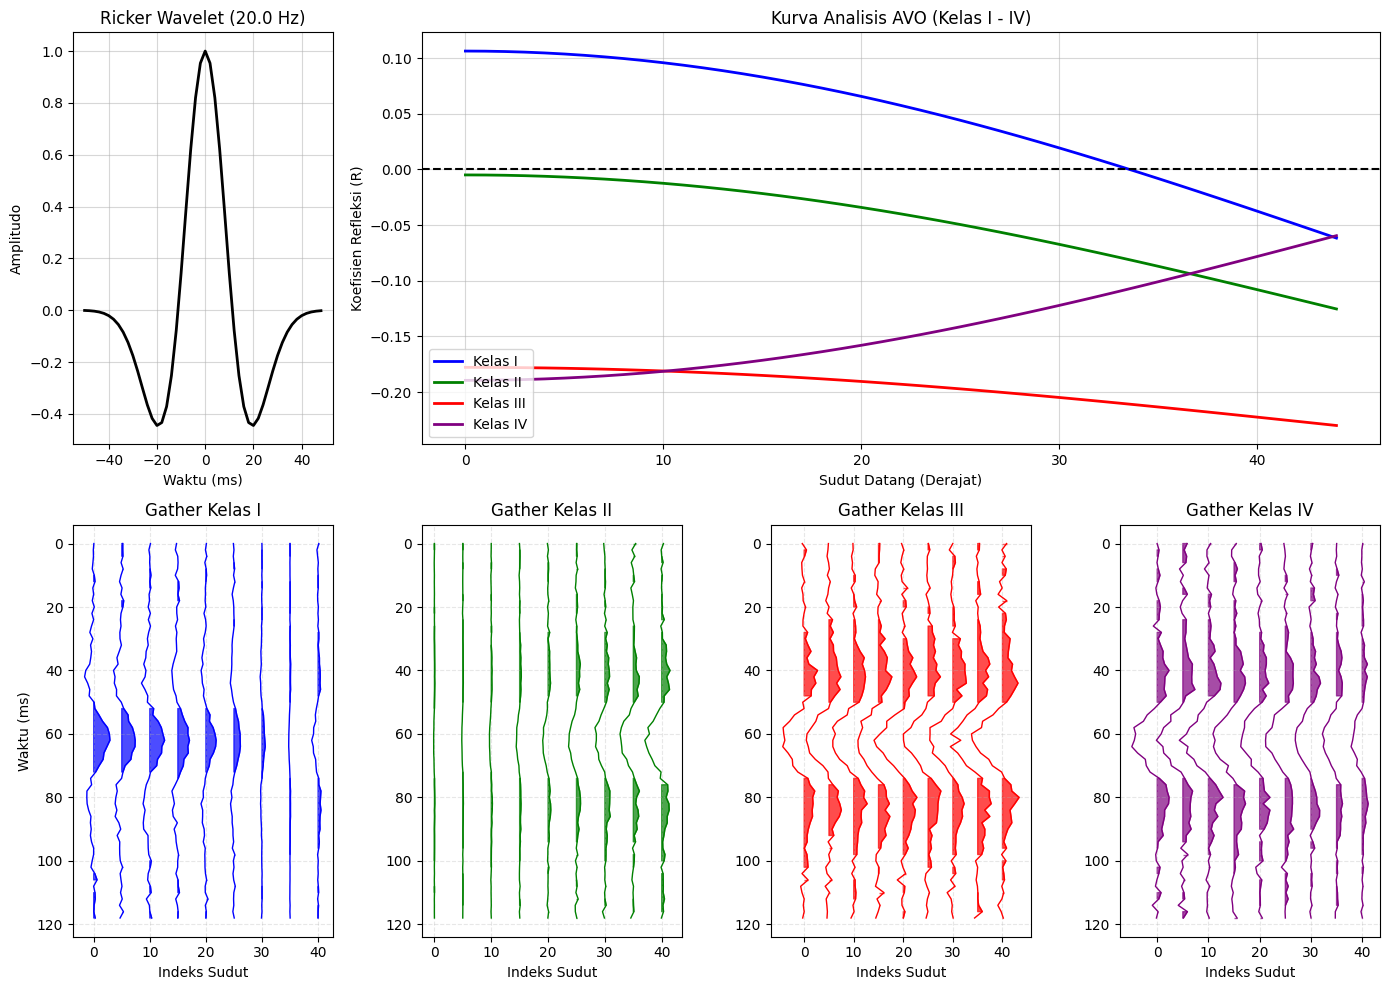


--- Memulai Generasi Dataset ML (Multi-Class) ---
Bentuk Input Data (X): (1000, 60, 9) -> (1000 Sampel, 60 Waktu, 9 Sudut)
Bentuk Target Regresi (y_prop): (1000, 3) -> (Vp, Vs, Rho)
Bentuk Target Klasifikasi (y_label): (1000,) -> (ID Kelas 0-3)

Dataset berhasil disimpan di: ./seismic_avo_dataset/
Siap untuk dimasukkan ke dalam arsitektur CNN atau BiLSTM!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNGSI FISIKA DASAR & NOISE
# ==========================================
def shuey_2term(vp1, vs1, rho1, vp2, vs2, rho2, angles_deg):
    dvp = vp2 - vp1
    dvs = vs2 - vs1
    drho = rho2 - rho1
    vp_avg = (vp1 + vp2) / 2.0
    vs_avg = (vs1 + vs2) / 2.0
    rho_avg = (rho1 + rho2) / 2.0
    
    A = 0.5 * (dvp / vp_avg + drho / rho_avg)
    B = 0.5 * (dvp / vp_avg) - 2.0 * (vs_avg / vp_avg)**2 * (drho / rho_avg + 2.0 * dvs / vs_avg)
    
    theta_rad = np.radians(angles_deg)
    R_theta = A + B * np.sin(theta_rad)**2
    return R_theta, A, B

def ricker_wavelet(freq, length, dt):
    t = np.arange(-length/2, (length)/2, dt)
    y = (1.0 - 2.0 * (np.pi**2) * (freq**2) * (t**2)) * np.exp(-(np.pi**2) * (freq**2) * (t**2))
    return t, y

def add_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    if signal_power == 0: return signal
    noise_power = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

# ==========================================
# 2. PARAMETERISASI 4 KELAS AVO
# ==========================================
# Definisi base properties untuk masing-masing kelas (Lapisan 1: Shale, Lapisan 2: Sand)
avo_classes = {
    "Kelas I":   {"vp1": 3300, "vs1": 1700, "rho1": 2.35, "vp2": 4000, "vs2": 2400, "rho2": 2.40},
    "Kelas II":  {"vp1": 3000, "vs1": 1500, "rho1": 2.40, "vp2": 3100, "vs2": 1900, "rho2": 2.30},
    "Kelas III": {"vp1": 3000, "vs1": 1500, "rho1": 2.40, "vp2": 2400, "vs2": 1600, "rho2": 2.10},
    "Kelas IV":  {"vp1": 3200, "vs1": 1600, "rho1": 2.40, "vp2": 2500, "vs2": 1100, "rho2": 2.10}
}

angles = np.arange(0, 45, 5) # Sudut observasi 0-40 derajat
angles_smooth = np.arange(0, 45, 1) # Untuk kurva AVO yang mulus
freq_wavelet = 20.0          # Frekuensi menengah (kompromi kedalaman medium-deep)
dt = 0.002                   # 2 ms sampling rate
snr_display = 12.0           # SNR 12 dB untuk visualisasi
n_samples = 60 
reflector_index = int(n_samples / 2)
time_axis = np.arange(0, n_samples * dt, dt) * 1000 

t_wavelet, wavelet = ricker_wavelet(freq_wavelet, length=0.1, dt=dt)

# ==========================================
# 3. VISUALISASI KOMPREHENSIF
# ==========================================
fig = plt.figure(figsize=(14, 10))
colors = ['blue', 'green', 'red', 'purple']

# --- Plot 1: Wavelet ---
ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=1)
ax1.plot(t_wavelet * 1000, wavelet, color='black', lw=2)
ax1.set_title(f"Ricker Wavelet ({freq_wavelet} Hz)")
ax1.set_xlabel("Waktu (ms)")
ax1.set_ylabel("Amplitudo")
ax1.grid(True, alpha=0.5)

# --- Plot 2: Kurva AVO ---
ax2 = plt.subplot2grid((2, 4), (0, 1), colspan=3)
for (name, props), color in zip(avo_classes.items(), colors):
    R_t_smooth, _, _ = shuey_2term(props['vp1'], props['vs1'], props['rho1'], 
                                   props['vp2'], props['vs2'], props['rho2'], angles_smooth)
    ax2.plot(angles_smooth, R_t_smooth, label=name, color=color, linewidth=2)

ax2.axhline(0, color='black', linestyle='--')
ax2.set_title("Kurva Analisis AVO (Kelas I - IV)")
ax2.set_xlabel("Sudut Datang (Derajat)")
ax2.set_ylabel("Koefisien Refleksi (R)")
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.5)

# --- Plot 3-6: Synthetic Gathers per Kelas ---
gathers = {}
for name, props in avo_classes.items():
    R_t, _, _ = shuey_2term(props['vp1'], props['vs1'], props['rho1'], 
                            props['vp2'], props['vs2'], props['rho2'], angles)
    gather = np.zeros((n_samples, len(angles)))
    for i, r in enumerate(R_t):
        rc = np.zeros(n_samples)
        rc[reflector_index] = r 
        trace = np.convolve(rc, wavelet, mode='same')
        gather[:, i] = add_noise(trace, snr_display)
    gathers[name] = gather

for idx, (name, gather) in enumerate(gathers.items()):
    ax = plt.subplot2grid((2, 4), (1, idx))
    for i, angle in enumerate(angles):
        trace_offset = gather[:, i] * 5 + i 
        ax.plot(trace_offset, time_axis, color=colors[idx], linewidth=1)
        ax.fill_betweenx(time_axis, i, trace_offset, where=(trace_offset > i), color=colors[idx], alpha=0.7)
    
    ax.invert_yaxis()
    ax.set_title(f"Gather {name}")
    if idx == 0: ax.set_ylabel("Waktu (ms)")
    ax.set_xlabel("Indeks Sudut")
    ax.set_xticks(np.arange(len(angles))[::2])
    ax.set_xticklabels(angles[::2])
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 4. GENERASI DATASET ML BERSKALA BESAR
# ==========================================
print("\n--- Memulai Generasi Dataset ML (Multi-Class) ---")
num_samples_per_class = 250 # Total 1000 sampel (4 kelas x 250)
X_data = [] # Fitur: Sinyal Seismik (Gather)
y_properties = [] # Target Regresi: [Vp2, Vs2, Rho2]
y_labels = [] # Target Klasifikasi: ID Kelas (0, 1, 2, 3)

class_names = list(avo_classes.keys())

for class_id, class_name in enumerate(class_names):
    base_props = avo_classes[class_name]
    
    for _ in range(num_samples_per_class):
        # Monte Carlo: Acak nilai +/- 5% agar data bervariasi
        vp1 = np.random.normal(base_props['vp1'], base_props['vp1'] * 0.05)
        vs1 = np.random.normal(base_props['vs1'], base_props['vs1'] * 0.05)
        rho1 = np.random.normal(base_props['rho1'], base_props['rho1'] * 0.05)
        
        vp2 = np.random.normal(base_props['vp2'], base_props['vp2'] * 0.05)
        vs2 = np.random.normal(base_props['vs2'], base_props['vs2'] * 0.05)
        rho2 = np.random.normal(base_props['rho2'], base_props['rho2'] * 0.05)
        
        R_t, _, _ = shuey_2term(vp1, vs1, rho1, vp2, vs2, rho2, angles)
        
        gather = np.zeros((n_samples, len(angles)))
        for i, r in enumerate(R_t):
            rc = np.zeros(n_samples)
            rc[reflector_index] = r
            trace = np.convolve(rc, wavelet, mode='same')
            random_snr = np.random.uniform(5.0, 15.0) # Noise bervariasi 5-15 dB
            gather[:, i] = add_noise(trace, random_snr)
            
        X_data.append(gather)
        y_properties.append([vp2, vs2, rho2])
        y_labels.append(class_id) # Simpan ID Kelas (0=I, 1=II, 2=III, 3=IV)

X_data = np.array(X_data)
y_properties = np.array(y_properties)
y_labels = np.array(y_labels)

print(f"Bentuk Input Data (X): {X_data.shape} -> (1000 Sampel, 60 Waktu, 9 Sudut)")
print(f"Bentuk Target Regresi (y_prop): {y_properties.shape} -> (Vp, Vs, Rho)")
print(f"Bentuk Target Klasifikasi (y_label): {y_labels.shape} -> (ID Kelas 0-3)")

# Simpan dataset
save_dir = "./seismic_avo_dataset"
os.makedirs(save_dir, exist_ok=True)

np.save(f"{save_dir}/X_gathers.npy", X_data)
np.save(f"{save_dir}/y_properties.npy", y_properties)
np.save(f"{save_dir}/y_labels.npy", y_labels)

print(f"\nDataset berhasil disimpan di: {save_dir}/")
print("Siap untuk dimasukkan ke dalam arsitektur CNN atau BiLSTM!")